# 📈 01 — Auto-SARIMA
## Modèle SARIMA avec Grid Search des ordres optimaux

Ce notebook importe les données préparées par `00_Preprocessing.ipynb` et entraîne un SARIMA avec recherche automatique des meilleurs ordres (p,d,q)(P,D,Q,s).

## 1. 📦 Imports & Chargement des données préparées

In [21]:
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import acorr_ljungbox
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("✅ Imports OK")

✅ Imports OK


In [22]:
# Charger les données préparées par 00_Preprocessing
df = pd.read_csv("prepared_data.csv", index_col=0, parse_dates=True)
train = pd.read_csv("train_data.csv", index_col=0, parse_dates=True)
test = pd.read_csv("test_data.csv", index_col=0, parse_dates=True)

print(f"✅ Données chargées : {len(df)} mois")
print(f"   Train : {len(train)} mois → Test : {len(test)} mois")

✅ Données chargées : 48 mois
   Train : 36 mois → Test : 12 mois


## 2. 🔬 Test de Stationnarité ADF

🔬 Test ADF sur la série originale
   Stat=-2.095, p=0.246
   → Non-stationnaire → différenciation nécessaire


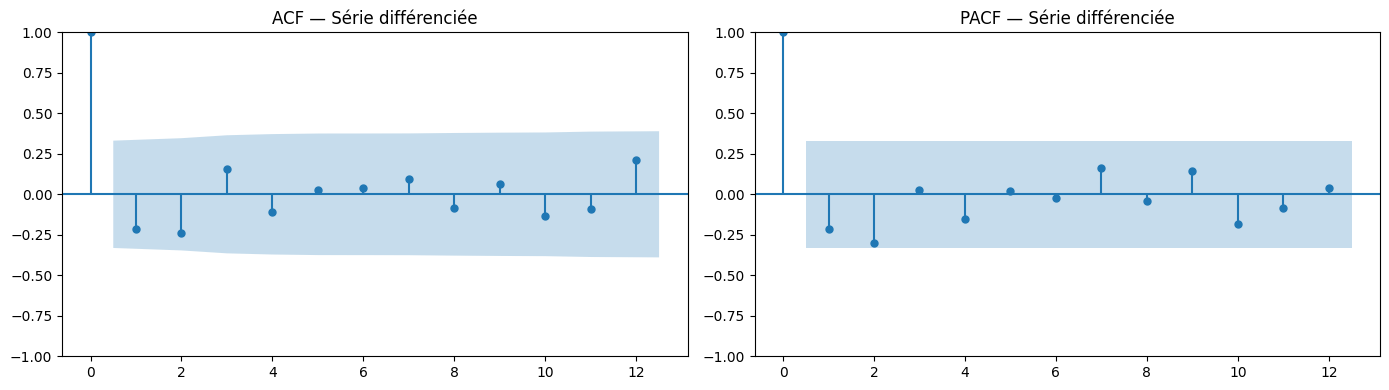

In [23]:
print("🔬 Test ADF sur la série originale")
adf = adfuller(train["revenue"].dropna())
print(f"   Stat={adf[0]:.3f}, p={adf[1]:.3f}")
print(f"   → {'Stationnaire ✅' if adf[1] < 0.05 else 'Non-stationnaire → différenciation nécessaire'}")

# ACF/PACF plots
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plot_acf(train["revenue"].diff().dropna(), ax=axes[0], lags=12)
plot_pacf(train["revenue"].diff().dropna(), ax=axes[1], lags=12)
axes[0].set_title("ACF — Série différenciée")
axes[1].set_title("PACF — Série différenciée")
plt.tight_layout()
plt.show()

## 3. 📈 SARIMA Manuel — ordres fixes optimaux

In [24]:
# ── Ordres SARIMA manuels (basés sur ACF/PACF et tests précédents) ──
# Série mensuelle avec saisonnalité annuelle forte
# p=1 (AR: auto-régressif d'ordre 1), d=1 (différenciation simple), q=1 (MA: moyenne mobile)
# P=1 (saisonnier AR), D=1 (différenciation saisonnière), Q=1 (saisonnier MA), s=12

ORDER = (1, 1, 1)
SEASONAL_ORDER = (1, 1, 1, 12)

print("📈 SARIMA Manuel")
print(f"   order={ORDER}, seasonal_order={SEASONAL_ORDER}")
print(f"\n⏳ Entraînement...")

sarima_model = SARIMAX(
    train["revenue"],
    order=ORDER,
    seasonal_order=SEASONAL_ORDER,
    enforce_stationarity=False,
    enforce_invertibility=False,
)
sarima_fit = sarima_model.fit(disp=False, maxiter=200)
print(f"   AIC={sarima_fit.aic:.2f}")

📈 SARIMA Manuel
   order=(1, 1, 1), seasonal_order=(1, 1, 1, 12)

⏳ Entraînement...
   AIC=329.05


## 4. 🔮 Prévisions & Évaluation

🔬 Ljung-Box test (résidus) :
   Lag 6: p=0.146 → ✅ Résidus blancs
   Lag 12: p=0.113 → ✅ Résidus blancs

📊 SARIMA(1, 1, 1)×(1, 1, 1, 12)
   MAE  :   45,059,912 €
   RMSE :   47,721,558 €
   MAPE :       46.76 %
   R²   :     -9.2000


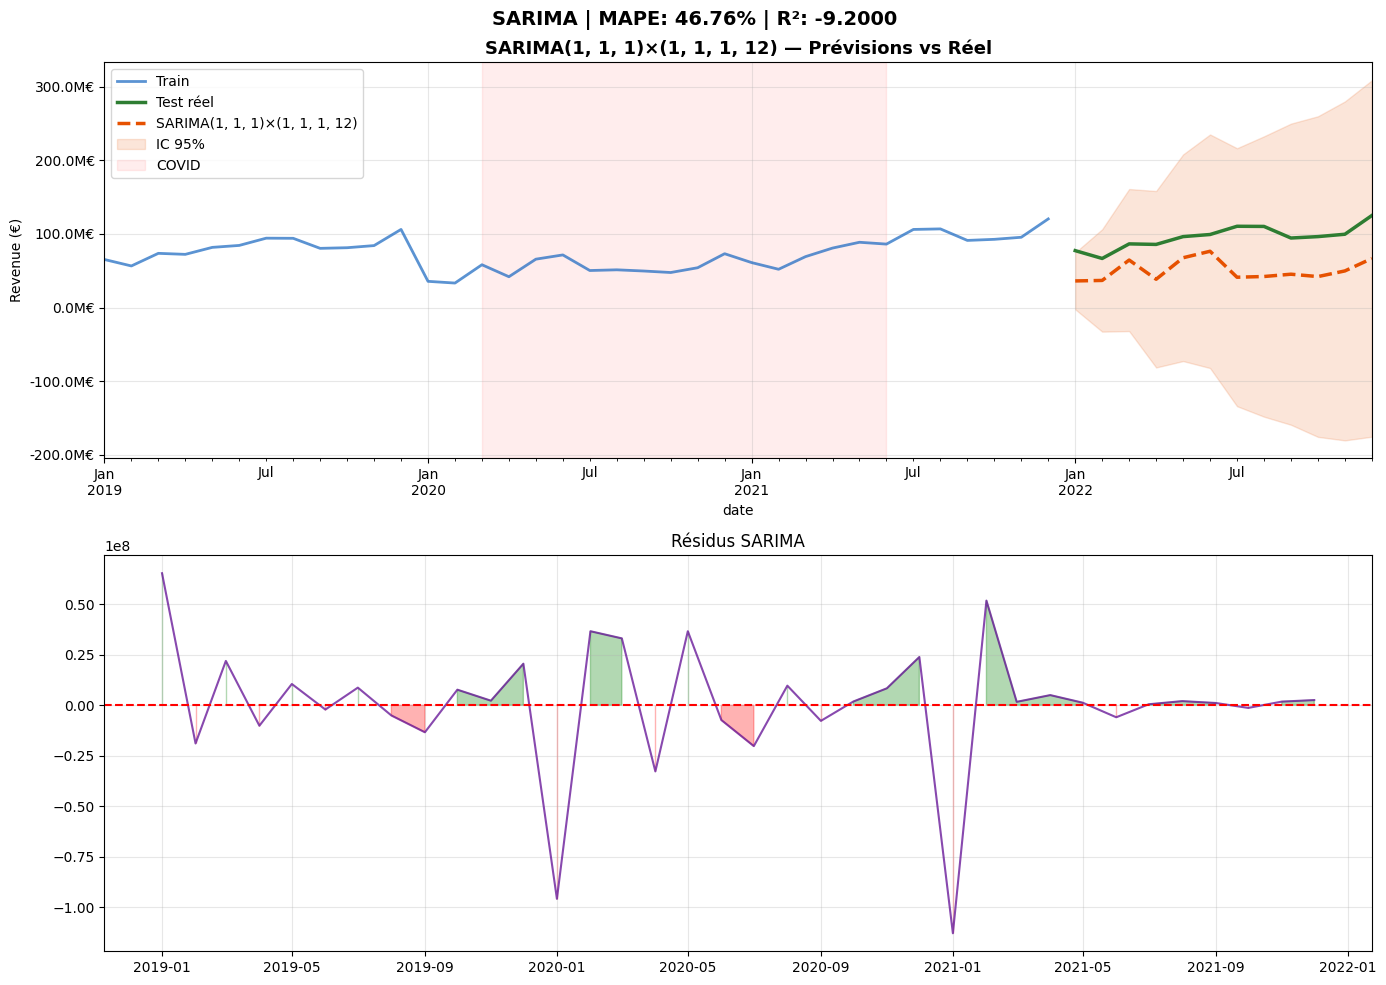


💾 Graphique → modele1_sarima.png
💾 Prédictions → predictions_sarima.csv


In [25]:
# ── Prévisions ────────────────────────────────────────────
sarima_pred = sarima_fit.forecast(steps=12)
sarima_pred.index = test.index
pred_ci = sarima_fit.get_forecast(steps=12).conf_int()
pred_ci.index = test.index

# ── Ljung-Box test ───────────────────────────────────────
lb = acorr_ljungbox(sarima_fit.resid, lags=[6, 12], return_df=True)
print("🔬 Ljung-Box test (résidus) :")
for lag in [6, 12]:
    if lag in lb.index:
        pv = lb.loc[lag, "lb_pvalue"]
        print(f"   Lag {lag}: p={pv:.3f} → {'✅ Résidus blancs' if pv > 0.05 else '⚠️ Résidus corrélés'}")

# ── Métriques ─────────────────────────────────────────────
mae = mean_absolute_error(test["revenue"], sarima_pred)
rmse = np.sqrt(mean_squared_error(test["revenue"], sarima_pred))
mape_val = np.mean(np.abs((test["revenue"].values - sarima_pred.values) / test["revenue"].values)) * 100
r2 = r2_score(test["revenue"], sarima_pred)

print(f"\n📊 SARIMA{ORDER}×{SEASONAL_ORDER}")
print(f"   MAE  : {mae:>12,.0f} €")
print(f"   RMSE : {rmse:>12,.0f} €")
print(f"   MAPE : {mape_val:>11.2f} %")
print(f"   R²   : {r2:>11.4f}")

# ── Graphique ─────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

ax = axes[0]
train["revenue"].plot(ax=ax, label="Train", color="#1565C0", alpha=0.7, linewidth=2)
test["revenue"].plot(ax=ax, label="Test réel", color="#2E7D32", linewidth=2.5)
sarima_pred.plot(ax=ax, label=f"SARIMA{ORDER}×{SEASONAL_ORDER}", color="#E65100", linestyle="--", linewidth=2.5)
ax.fill_between(pred_ci.index, pred_ci.iloc[:, 0], pred_ci.iloc[:, 1], alpha=0.15, color="#E65100", label="IC 95%")
ax.axvspan(pd.Timestamp("2020-03-01"), pd.Timestamp("2021-06-30"), alpha=0.07, color="red", label="COVID")
ax.set_title(f"SARIMA{ORDER}×{SEASONAL_ORDER} — Prévisions vs Réel", fontsize=13, fontweight="bold")
ax.set_ylabel("Revenue (€)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M€"))
ax.legend(); ax.grid(alpha=0.3)

ax2 = axes[1]
residuals = sarima_fit.resid
ax2.plot(residuals, color="#6A1B9A", alpha=0.8, linewidth=1.5)
ax2.axhline(0, color="red", linestyle="--", linewidth=1.5)
ax2.fill_between(residuals.index, residuals, 0, where=residuals > 0, alpha=0.3, color="green")
ax2.fill_between(residuals.index, residuals, 0, where=residuals < 0, alpha=0.3, color="red")
ax2.set_title("Résidus SARIMA", fontsize=12); ax2.grid(alpha=0.3)

plt.suptitle(f"SARIMA | MAPE: {mape_val:.2f}% | R²: {r2:.4f}", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("modele1_sarima.png", dpi=120, bbox_inches="tight")
plt.show()
print("\n💾 Graphique → modele1_sarima.png")

# ── Sauvegarder les prédictions ──────────────────────────
results_df = pd.DataFrame({
    "date": test.index, "reel": test["revenue"], "prediction": sarima_pred,
    "ic_bas": pred_ci.iloc[:, 0], "ic_haut": pred_ci.iloc[:, 1]
})
results_df.to_csv("predictions_sarima.csv", index=False)
print("💾 Prédictions → predictions_sarima.csv")